# Compare methods

以下2点とcossimを組み合わせて評価する

- Faithful
  - 評価方法(WYMと同じ)
    - TokenPairのみのEntityPairでのマッチャー結果と、元のマッチャー結果とが同じとなる確率
  - 計測対象のレコードペア
    - マッチャーがMatchの結果をだしたレコードのみ or 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> match_score(k token pair のみ追加した時の match score)
- Contribution
  - 評価方法(WYMと同じ)
    - TokenPairを削除したEntityPairのマッチャー結果でのF1スコアのMoRF
  - 計測対象のレコードペア
    - マッチャーがMatchの結果を出したレコードのみ OR 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> match_score(k token pair のみ削除した時の match score)
- TokenPairのわかりやすさ
  - 評価方法（今までと同じ）
    - コサイン類似度
  - 計測対象のレコードペア
    - マッチャーがMatchの結果を出したレコードのみ OR 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method
    - dataid -> k -> cos_sim(k token pair 番目のcos sim)
- TokenPairのわかりやすさ Wordnet利用
  - 評価方法
    - wordnetのLCSを利用したスコア(Wu & Palmer Similarity)
  - 計測対象のレコードペア
    - 全部
  - 比較
    - 全手法比較
  - 必要なデータ
    - dataset -> matcher -> method

これらの組合せで総合指標を作る



In [1]:
matcher_names = ["bert_mini", "magellan"]
dataset_root_dir = "../../data/lemon/datasets"
eval_data_root_dir = "../../data/experiments/11_eval"
lime_result_root_dir = "../../data/experiments/10_eval/lime_result"
token_sim_result_root_dir = "../../data/experiments/10_eval/sim_token_score"
token_sim_wup_result_root_dir = "../../data/experiments/11_eval/sim_token_score_wup"
dataset_names = [
    "structured_amazon_google",
    "structured_beer",
    "structured_dblp_acm",
    "structured_dblp_google_scholar",
    "structured_fodors_zagat",
    "structured_walmart_amazon",
    "structured_itunes_amazon",
    "dirty_dblp_acm",
    "dirty_dblp_google_scholar",
    "dirty_walmart_amazon",
    "dirty_itunes_amazon",
    "textual_abt_buy",
    "textual_company",
]
methods = [
    "pine",  # PINE
    "lime_pair",  # LIME_pair
    "cossim",  # CosSim
    "lime_ranked",  # LIME_r
    "lemon_ranked",  # LEMON_r
]

target_dataset_idxs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
target_matcher_idxs = [0, 1]
target_method_idxs = [0, 1, 2, 3, 4]

In [2]:
TOP_N = 5

In [3]:
# グラフ内に表示する名前に変換する対応表
## 用いないもの以外は、コメントアウトしておく（これにより、表示時に間違えないようにする）
matcher_names_maps = {
    "bert_mini": "DITTO",
    "magellan": "py_entitymatching",
}
datasetname_maps = {
    "structured_amazon_google": "S_AG",
    "structured_beer": "S_BE",
    "structured_dblp_acm": "S_DA",
    "structured_dblp_google_scholar": "S_DG",
    "structured_fodors_zagat": "S_FZ",
    "structured_walmart_amazon": "S_WA",
    "structured_itunes_amazon": "S_IA",
    "dirty_dblp_acm": "D_DA",
    "dirty_dblp_google_scholar": "D_DG",
    "dirty_walmart_amazon": "D_WA",
    "dirty_itunes_amazon": "D_IA",
    "textual_abt_buy": "T_AB",
}
methods_map = {
    "pine": "PINE",
    "cossim": "CosSim",
    "lime_pair": "LIME_Pair",
    "lime_ranked": "LIME_r",
    "lemon_ranked": "LEMON_r",
}
# メソッドに使うマーカーの種類（白黒でも対応できるように）
## マーカーの数は、target_method_idxs と同じ数
# markers = ["o", "v", "s", "x", "+", "x"]
markers = ["s", "d", "x", "+", "v", "o", "o"]
color_palette = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
line_styles = ["-", "--", "-.", ":", "-.", "-"]


## データセットを読み込む

In [4]:
from pine.dataset import load_dataset
from functools import lru_cache


@lru_cache(maxsize=None)
def test_load_dataset():
    dataset_name = dataset_names[target_dataset_idxs[0]]
    dataset = load_dataset(dataset_name, dataset_root_dir)
    display(dataset.test.records.a.head())
    display(dataset.test.records.b.head())
    display(dataset.test.record_id_pairs.head())
    display(dataset.test.labels.head())
    print(dataset.test.records.a.dtypes)
    print("Test DATA SIZE =", len(dataset.test.record_id_pairs))


test_load_dataset()

,title,manufacturer,price
__id,,,
0,clickart 950 000 premier image pack ( dvd-rom ),broderbund,<NA>
1,ca international arcserve lap/desktop oem 30pk,computer associates,<NA>
2,noah 's ark activity center ( jewel case ages ...,victory multimedia,<NA>
3,peachtree by sage premium accounting for nonpr...,sage software,599.99
4,singing coach unlimited,carry-a-tune technologies,99.99


,title,manufacturer,price
__id,,,
0,learning quickbooks 2007,intuit,38.99
1,superstart ! fun with reading & writing !,<NA>,8.49
2,qb pos 6.0 basic software,intuit,637.99
3,math missions : the amazing arcade adventure (...,<NA>,12.95
4,production prem cs3 mac upgrad,adobe software,805.99


,a.rid,b.rid
pid,,
0,393,831
1,559,324
2,558,3023
3,762,1618
4,1262,2860


pid
0    False
1    False
2    False
3    False
4    False
Name: label, dtype: bool

title            string
manufacturer     string
price           Float64
dtype: object
Test DATA SIZE = 2293


## Lime 結果を読み込む

オリジナルのmatch_scoreを取得するため

In [5]:
from typing import Dict, List, Tuple
import pathlib
import pickle
from dataclasses import dataclass
from pine.explainer import AttributionScore


@dataclass
class LimeResult:
    attributions_l: List[AttributionScore]
    attributions_r: List[AttributionScore]
    match_score: float
    lime_intercept: float
    lime_pred_score: float
    lime_match_score: float


@lru_cache(maxsize=None)
def load_lime_result(
    target_dataset_name: str,
    target_matcher_name: str,
    dir_path: pathlib.Path,
) -> Dict[int, Dict[Tuple[int, int], LimeResult]]:
    dir_path = dir_path / target_matcher_name / target_dataset_name
    id_to_pairdel_to_results = {}
    for file_path in dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)

        # lime結果を分かりやすいオブジェクトでラップする
        data_coverted = {}
        for id, result in data.items():
            data_coverted[id] = {}
            for k, v in result.items():
                data_coverted[id][k] = LimeResult(*v)

        id_to_pairdel_to_results.update(data_coverted)
    return id_to_pairdel_to_results


def test_load_lime_result():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    target_matcher_name = matcher_names[0]
    ret = load_lime_result(
        target_dataset_name, target_matcher_name, pathlib.Path(lime_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break


test_load_lime_result()

0
{(None, None): LimeResult(attributions_l=[AttributionScore(index=16, score=-0.005304679839918099), AttributionScore(index=9, score=-0.000763714890664954), AttributionScore(index=0, score=0.0007354459772700248), AttributionScore(index=8, score=-0.0004981564328716827), AttributionScore(index=12, score=-0.0004104501516031153), AttributionScore(index=10, score=-0.0003882142183173817), AttributionScore(index=5, score=-0.0003314801390453024), AttributionScore(index=4, score=-0.0002955279607824098), AttributionScore(index=14, score=-0.00021610068271735655), AttributionScore(index=1, score=-0.00018889071214605235), AttributionScore(index=15, score=-0.00013449541630198436), AttributionScore(index=3, score=0.0001335954755108168), AttributionScore(index=11, score=-0.00011764262659202217), AttributionScore(index=6, score=9.905549526097899e-05), AttributionScore(index=2, score=5.754800339219912e-05), AttributionScore(index=13, score=-5.428105174915632e-05), AttributionScore(index=7, score=-1.1375

## 各手法のpair explanationデータを取得

In [6]:
from pine.entity import EntityPair


@dataclass
class LimeResultPair:
    attributions: List[AttributionScore]
    match_score: float
    lime_intercept: float
    lime_pred_score: float
    lime_match_score: float


@lru_cache(maxsize=None)
def load_pair_explanations(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    pair_explanation_root_dir_path: pathlib.Path = None,
) -> Dict[int, Tuple[LimeResultPair, EntityPair]]:
    pair_explanations_file_path = (
        pair_explanation_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "pair_explanations.pickle"
    )

    with pair_explanations_file_path.open("rb") as f_in:
        pair_explanations = pickle.load(f_in)
    # もともと、PairExplanationはattrinution score の絶対値の大きい順で並んでいる。今回はそのまま使う。
    return pair_explanations


def test_load_pair_explanations():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    target_matcher_name = matcher_names[0]
    target_method_name = methods[0]
    pair_explanations = load_pair_explanations(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (idx, exp) in enumerate(pair_explanations.items()):
        print(idx)
        print(exp)
        if i >= 10:
            break


test_load_pair_explanations()

0
(LimeResultPair(attributions=[AttributionScore(index=4, score=-0.004111583144267731), AttributionScore(index=3, score=0.000940985355855317), AttributionScore(index=1, score=-0.0007373148027706093), AttributionScore(index=0, score=-0.0003356608000932227), AttributionScore(index=2, score=3.285103323043384e-05)], match_score=-0.9362620115280151, lime_intercept=-0.9317222289148563, lime_pred_score=0.816040447460189, lime_match_score=-0.9359329512729021), <pine.entity.EntityPair object at 0x7f50680d7dd0>)
1
(LimeResultPair(attributions=[AttributionScore(index=3, score=-0.0025692246356358835), AttributionScore(index=2, score=0.0016349360853050244), AttributionScore(index=0, score=-0.00012123288565712969), AttributionScore(index=1, score=3.260996248613128e-05)], match_score=-0.9363967776298523, lime_intercept=-0.9347282170761005, lime_pred_score=0.5292448216409281, lime_match_score=-0.9357511285496024), <pine.entity.EntityPair object at 0x7f4fb5bd5910>)
2
(LimeResultPair(attributions=[Attri

### レコードペアの全トークンペアのコサイン類似度データを読み込む

In [7]:
@lru_cache(maxsize=None)
def load_token_sim_score(
    target_dataset_name: str,
    dir_path: pathlib.Path,
) -> Dict[int, Dict[Tuple[int, int], float]]:
    dir_path = dir_path / target_dataset_name
    id_to_sim = {}
    for file_path in dir_path.glob("*.pickle"):
        with file_path.open("rb") as f:
            data = pickle.load(f)
        id_to_sim.update(data)
    return id_to_sim


def test_load_token_sim_score():
    target_dataset_name = dataset_names[target_dataset_idxs[0]]
    print("All Cos Sim")
    ret = load_token_sim_score(
        target_dataset_name, pathlib.Path(token_sim_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break
    print("All WUP Sim")
    ret = load_token_sim_score(
        target_dataset_name, pathlib.Path(token_sim_wup_result_root_dir)
    )
    for i, (idx, pair_scores) in enumerate(ret.items()):
        print(idx)
        print(pair_scores)
        if i >= 10:
            break


test_load_token_sim_score()

All Cos Sim
0
{(0, 0): 0.6716153, (0, 1): 0.8743831, (0, 2): 0.83280313, (0, 3): 0.7802479, (0, 4): 0.99999994, (0, 5): 0.8221581, (0, 6): 0.7724519, (0, 7): 0.47965723, (1, 0): 0.7359337, (1, 1): 0.8886341, (1, 2): 0.8370592, (1, 3): 0.7877052, (1, 4): 0.8600425, (1, 5): 0.84350866, (1, 6): 0.7764783, (1, 7): 0.50858474, (2, 0): 0.7185588, (2, 1): 0.8273668, (2, 2): 0.7849426, (2, 3): 0.72297615, (2, 4): 0.77928287, (2, 5): 0.83217937, (2, 6): 0.72730255, (2, 7): 0.49210495, (3, 0): 0.7510818, (3, 1): 0.8404385, (3, 2): 0.8225287, (3, 3): 0.7634133, (3, 4): 0.8190682, (3, 5): 0.8643153, (3, 6): 0.78120387, (3, 7): 0.53212273, (4, 0): 0.6851623, (4, 1): 0.83169794, (4, 2): 0.851985, (4, 3): 0.7596642, (4, 4): 0.80878055, (4, 5): 0.8988457, (4, 6): 0.76653284, (4, 7): 0.5062798, (5, 0): 0.65613425, (5, 1): 0.7882945, (5, 2): 0.7839142, (5, 3): 0.7290906, (5, 4): 0.7820235, (5, 5): 0.7895247, (5, 6): 0.94505084, (5, 7): 0.55955213, (6, 0): 0.6788143, (6, 1): 0.7224215, (6, 2): 0.68044996

## 各種手法での k token pair まで追加した時の match score

In [8]:
import numpy as np


@lru_cache(maxsize=None)
def load_match_score_remain(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    data_root_dir_path: pathlib.Path = None,
) -> Dict[int, np.array]:
    file_path = (
        data_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "match_score_remains.pickle"
    )

    # print(str(file_path))
    with file_path.open("rb") as f_in:
        ret = pickle.load(f_in)
    return ret


def test_load_match_score_remain():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    target_matcher_name = matcher_names[0]
    target_method_name = methods[0]
    ret = load_match_score_remain(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (key, val) in enumerate(ret.items()):
        print(key)
        print(val)
        if i >= 10:
            break


test_load_match_score_remain()

0
[-0.10511875 -0.40629673 -0.4653654  -0.72137964 -0.865101   -0.9154297 ]
1
[-0.10511935 -0.40629643 -0.5253277  -0.1755594  -0.8054966 ]
2
[-0.10511935  0.5111655   0.5114753   0.5197884   0.52450264]
3
[-0.10511935 -0.44478816 -0.6268277  -0.19839776 -0.5859245  -0.84670264]
4
[-0.10511863  0.503777    0.50699854  0.50565386]
5
[-0.10511893 -0.4062969  -0.59752643 -0.65547705]
6
[-0.10511935  0.48024786  0.4845568   0.4674003   0.43166733  0.41306925]
7
[-0.10511875  0.5154406   0.50755906  0.47513282  0.48437476]
8
[-0.10511935  0.51105225  0.494267    0.4976461   0.52165043  0.520733  ]
9
[-0.10511863 -0.21519768 -0.21158868 -0.57210314]
10
[-0.10511875 -0.4878857  -0.6343904  -0.4967593  -0.7793233  -0.9013909 ]


## 各手法でのk token pair のみ削除した時の match score

In [9]:
import numpy as np


@lru_cache(maxsize=None)
def load_match_score_delete(
    target_method_name: str,
    target_dataset_name: str,
    target_matcher_name: str,
    data_root_dir_path: pathlib.Path = None,
) -> Dict[int, np.array]:
    file_path = (
        data_root_dir_path
        / target_method_name
        / target_matcher_name
        / target_dataset_name
        / "match_score_deletes.pickle"
    )

    with file_path.open("rb") as f_in:
        ret = pickle.load(f_in)
    return ret


def test_load_match_score_delete():
    TARGET_DATASET_ID = 1
    target_dataset_name = dataset_names[TARGET_DATASET_ID]
    target_matcher_name = matcher_names[0]
    target_method_name = methods[0]
    ret = load_match_score_delete(
        target_method_name,
        target_dataset_name,
        target_matcher_name,
        pathlib.Path(eval_data_root_dir),
    )
    for i, (key, val) in enumerate(ret.items()):
        print(key)
        print(val)
        if i >= 10:
            break


test_load_match_score_delete()

0
[-0.936262   -0.9298711  -0.92981106 -0.93014175 -0.9302686  -0.93246585]
1
[-0.9363968  -0.93136156 -0.931378   -0.9323467  -0.9365779 ]
2
[ 0.53362846  0.52561116 -0.04458404 -0.9129342  -0.9191526 ]
3
[-0.9354775  -0.92963487 -0.9273891  -0.9254809  -0.922085   -0.91972125]
4
[ 0.52147603  0.4938228  -0.8333901  -0.92752254]
5
[-0.9321163  -0.92760414 -0.925592   -0.92385334]
6
[ 0.4894029   0.45808375  0.44937062  0.46178007  0.45396864 -0.92032063]
7
[ 0.47323215 -0.9050771  -0.90858877 -0.9297536  -0.9310535 ]
8
[ 0.32301807  0.17946565 -0.05220765  0.36310935  0.4691428  -0.92736363]
9
[-0.93936306 -0.9353644  -0.93265885 -0.93681   ]
10
[-0.9349639  -0.9283967  -0.925549   -0.92251766 -0.9190017  -0.9195572 ]


## Faithful

In [11]:
from typing import Callable
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import set_matplotlib_formats
import pandas as pd
from tqdm import tqdm


def get_data_ids(
    dataset,
    lime_results,
    match_score_func: Callable = None,
    grand_truth: bool = None,
    dump: bool = False,
):
    data_ids_in_score_and_gt = []
    for data_id in lime_results.keys():
        if dump:
            print(lime_results[data_id][(None, None)].match_score)
        if (match_score_func is not None) and not match_score_func(
            lime_results[data_id][(None, None)].match_score
        ):
            continue
        if (grand_truth is not None) and dataset.test.labels.loc[
            data_id
        ] != grand_truth:
            continue
        data_ids_in_score_and_gt.append(data_id)
    return data_ids_in_score_and_gt



In [12]:
def display_graph(matcher_to_dataset_to_methods_to_data, metrics_name, x_axis_start=1):
    fig, axs = plt.subplots(
        len(target_matcher_idxs),
        len(target_dataset_idxs),
        squeeze=False,
        figsize=(1.2 * len(target_dataset_idxs), 1.5 * len(target_matcher_idxs)),
    )
    y_min = 0.0
    y_max = 1.0
    default_markersize = mpl.rcParams["lines.markersize"] - 2
    for i, target_matcher_idx in enumerate(target_matcher_idxs):
        target_matcher_name = matcher_names[target_matcher_idx]
        for j, target_dataset_idx in enumerate(target_dataset_idxs):
            target_dataset_name = dataset_names[target_dataset_idx]
            ax = axs[i, j]
            lines = {}
            for marker, color, linestyle, target_method_name in zip(
                markers,
                color_palette,
                line_styles,
                [methods[k] for k in target_method_idxs],
            ):
                # 一番初めのlineのみ、markerを大きくする
                marker_size = (
                    default_markersize if len(lines) != 0 else default_markersize + 3
                )
                data = matcher_to_dataset_to_methods_to_data[target_matcher_name][
                    target_dataset_name
                ][target_method_name]

                (line,) = ax.plot(
                    range(x_axis_start, TOP_N + 1),
                    data,
                    label=methods_map[target_method_name],
                    marker=marker,
                    markersize=marker_size,
                    color=color,
                    linestyle=linestyle,
                )
                lines[methods_map[target_method_name]] = line
            # X,Y軸のメモリは、下と左のみ表示
            ax.set_xticks([x_axis_start, 3, 5])
            if not ax.get_subplotspec().is_last_row():
                ax.tick_params(labelbottom=False)
            if not ax.get_subplotspec().is_first_col():
                ax.tick_params(labelleft=False)
            # タイトル、ラベル
            if ax.get_subplotspec().is_first_row():
                xlabel_fontsize = ax.xaxis.label.get_fontsize()
                ax.set_title(
                    datasetname_maps[target_dataset_name], fontsize=xlabel_fontsize
                )
            if ax.get_subplotspec().is_last_row():
                ax.set_xlabel("token pairs")
            if ax.get_subplotspec().is_first_col():
                ax.set_ylabel(
                    f"{matcher_names_maps[target_matcher_name]}\n {metrics_name}"
                )
            ax.grid(True)
    # Y軸の範囲を揃える
    for i, target_matcher_idx in enumerate(target_matcher_idxs):
        for j, target_dataset_idx in enumerate(target_dataset_idxs):
            ax = axs[i, j]
            ax.set_ylim(y_min - 0.05, y_max + 0.05)
    fig.legend(
        lines.values(),
        lines.keys(),
        fontsize="10",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=len(lines.keys()),
        columnspacing=4.0,
    )
    plt.tight_layout()  # グラフ同士の間隔を調整
    # plt.subplots_adjust(bottom=0.14)
    plt.show()
    return


In [13]:
def create_method_ranking(method2value):
    # valueの降順にソート
    sorted_value = sorted(method2value.items(), key=lambda x: x[1], reverse=True)

    method2rank = {}
    current_rank = 1  # 実際に付与するランク
    last_value = None  # 前回の value

    # enumerate の start=1 は 1 からカウントを始める
    for i, (method, acc) in enumerate(sorted_value, start=1):
        # 前回の値と異なる場合のみランクを更新
        if acc != last_value:
            current_rank = i
            last_value = acc
        method2rank[method] = current_rank

    return method2rank


def create_dataframe(dataset_to_methods_to_ranking, target_datasets, target_methods):
    """
    dataset_to_methods_to_ranking:
      {
          "datasetA": {
              "method1": {"posthoc_acc": 0.9,  "rank": 1},
              "method2": {"posthoc_acc": 0.8,  "rank": 2},
          },
          "datasetB": {
              "method1": {"posthoc_acc": 0.7,  "rank": 2},
              "method2": {"posthoc_acc": 0.85, "rank": 1},
          }
      }
    のような三重の辞書構造を想定。
    """

    # === 全てのmetricsを取得 ===
    all_metrics = set()
    for dataset in target_datasets:
        for method in target_methods:
            all_metrics.update(dataset_to_methods_to_ranking[dataset][method].keys())

    # === マルチインデックスのカラム作成 ===
    # 上位: method名
    # 下位: metrics名
    columns = pd.MultiIndex.from_tuples(
        [
            (methods_map[method], metric)
            for method in target_methods
            for metric in all_metrics
        ],
        names=["method", "metric"],
    )

    # === DataFrameを作るための行データをループで構築 ===
    #     行は各 dataset ごと
    data_rows = []
    index_labels = []
    for dataset in target_datasets:
        row_dict = {}
        for method in target_methods:
            for metric in all_metrics:
                # method が存在しない場合は NaN にする
                row_dict[(methods_map[method], metric)] = dataset_to_methods_to_ranking[
                    dataset
                ][method].get(metric, float("nan"))
        data_rows.append(row_dict)
        index_labels.append(datasetname_maps[dataset])

    # === DataFrame の作成 ===
    df = pd.DataFrame(data_rows, index=pd.Series(index_labels, name="dataset"))
    # 用意しておいたマルチインデックスを列に適用
    df.columns = columns
    return df


def make_ranking_table(
    dataset_to_methods_to_posthoc_acc: Dict[str, List[float]],
    target_pair_num: int,
    metric_name: str,
):
    """pandas.Dataframeで、metric_nameのランキングのテーブルを作成
    縦軸にデータセット名、横軸に手法名、値にmetric_nameとデータセット内での手法のランキングを持つ
    このテーブルを使って、ランキングを表示"""
    dataset_to_methods_to_ranking = {}
    for target_dataset_name in dataset_to_methods_to_posthoc_acc.keys():
        dataset_to_methods_to_ranking[target_dataset_name] = {}
        target_method_names = dataset_to_methods_to_posthoc_acc[
            target_dataset_name
        ].keys()
        for target_method_name in target_method_names:
            metric_value = dataset_to_methods_to_posthoc_acc[target_dataset_name][
                target_method_name
            ][target_pair_num - 1]
            # metric_value を小数点4位で丸める
            metric_value = round(metric_value, 4)
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name] = {}
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name][
                metric_name
            ] = metric_value
        ranks = create_method_ranking(
            {
                target_method_name: dataset_to_methods_to_ranking[target_dataset_name][
                    target_method_name
                ][metric_name]
                for target_method_name in target_method_names
            }
        )
        for target_method_name in target_method_names:
            dataset_to_methods_to_ranking[target_dataset_name][target_method_name][
                "ranking"
            ] = ranks[target_method_name]
    df = create_dataframe(
        dataset_to_methods_to_ranking,
        [dataset_names[dataset_idx] for dataset_idx in target_dataset_idxs],
        [methods[method_idx] for method_idx in target_method_idxs],
    )
    return df


In [14]:
def _calc_post_hoc_acc(
    rank,
    match_scores_pertub,
    lime_results: Dict[int, Dict[Tuple[int, int], LimeResult]],
) -> Tuple[float, int, int]:
    match_scores_pertub_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    match_scores_org_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    for i, pid in enumerate(match_scores_pertub):
        match_scores_pertub_ = match_scores_pertub[pid]
        # 削除できるものがない場合、この前のスコアを採用
        if match_scores_pertub_.size < rank + 1:
            match_scores_pertub_ = np.pad(
                match_scores_pertub[pid],
                (0, rank + 1 - match_scores_pertub_.size),
                "edge",
            )
        match_scores_pertub_arr[i] = match_scores_pertub_[rank]
        match_scores_org_arr[i] = lime_results[pid][(None, None)].match_score
    assert np.sum(np.isnan(match_scores_pertub_arr)) == 0
    y = (match_scores_org_arr > 0).astype(int)
    y_pred = (match_scores_pertub_arr > 0).astype(int)
    return np.mean(y == y_pred), len(y_pred), (y == y_pred).sum()


def make_faithful_graph_data(match_score_func, grand_truth):
    matcher_to_dataset_to_methods_to_posthoc_acc = {}
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                target_dataset_name
            ] = {}

            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {}
                # 結果スコアをロード
                match_score_remain = load_match_score_remain(
                    target_method_name,
                    target_dataset_name,
                    target_matcher_name,
                    pathlib.Path(eval_data_root_dir),
                )
                # 条件に合うdata_idのみで平均とデータ数を計算
                match_score_remain = {
                    data_id: match_score_remain[data_id] for data_id in data_ids
                }
                # posthoc accuracyを計算
                acc_list = []
                data_num_list = []
                correct_num_list = []
                for i in range(TOP_N + 1):
                    acc, data_num, correct_num = _calc_post_hoc_acc(
                        i, match_score_remain, lime_results
                    )
                    acc_list.append(acc)
                    data_num_list.append(data_num)
                    correct_num_list.append(correct_num)
                matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {
                    "accuracy": acc_list,
                    "data_num": data_num_list,
                    "correct_num": correct_num_list,
                }
    return matcher_to_dataset_to_methods_to_posthoc_acc


def display_faithful_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
):
    # グラフ描画用データ取得
    matcher_to_dataset_to_methods_to_posthoc_acc = make_faithful_graph_data(
        match_score_func, grand_truth
    )
    matcher_to_dataset_to_methods_to_posthoc_acc_data = {
        k1: {
            k2: {k3: v["accuracy"][1:] for k3, v in d2.items()} for k2, d2 in d1.items()
        }
        for k1, d1 in matcher_to_dataset_to_methods_to_posthoc_acc.items()
    }
    # グラフ描画
    display_graph(matcher_to_dataset_to_methods_to_posthoc_acc_data, "ph_accuracy")

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_acc_data[target_matcher_name],
                TOP_N,
                "post_hoc_acc",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

loading data for bert_mini


100%|██████████| 12/12 [00:01<00:00, 10.18it/s]


loading data for magellan


100%|██████████| 12/12 [00:01<00:00, 10.74it/s]


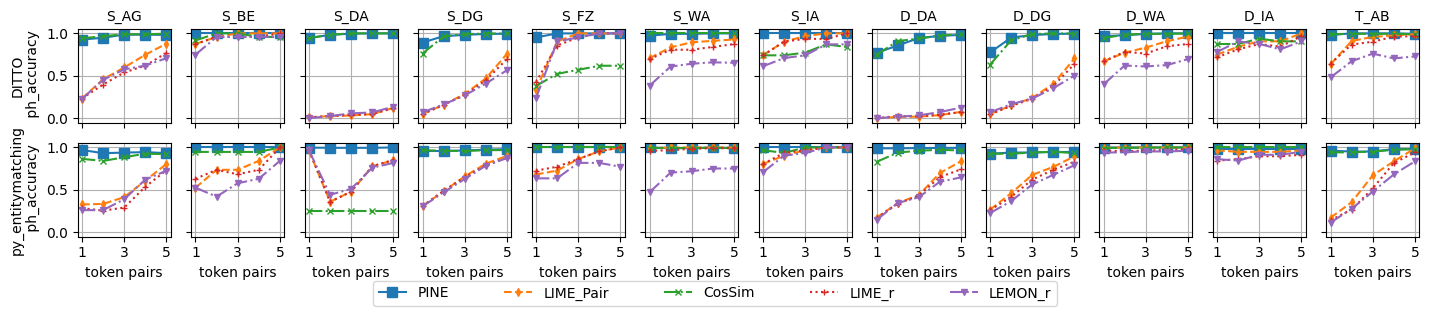

In [16]:
display_faithful_graph(match_score_func=lambda x: x >= 0.0, show_table=False)

loading data for bert_mini


100%|██████████| 12/12 [00:02<00:00,  5.97it/s]


loading data for magellan


100%|██████████| 12/12 [00:01<00:00,  7.36it/s]


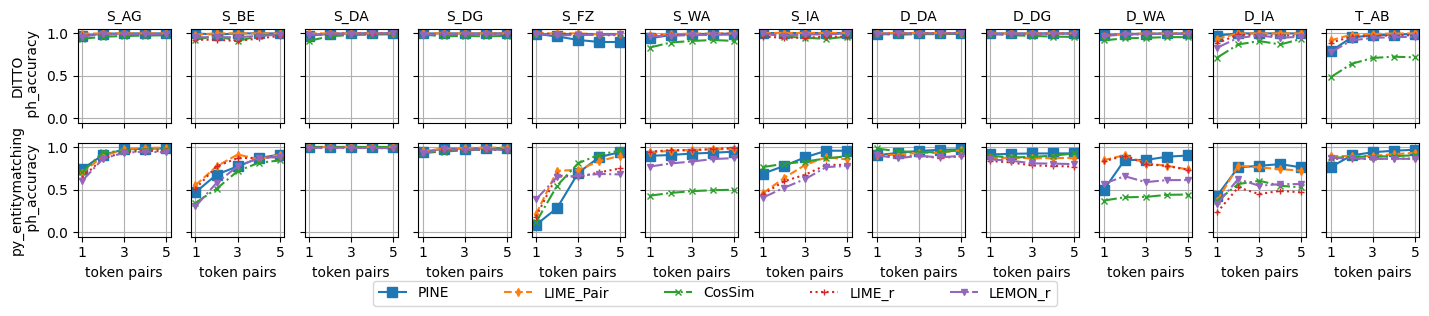

In [17]:
display_faithful_graph(match_score_func=lambda x: x < 0.0, show_table=False)

## Contribution

In [18]:
from typing import Callable
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
import pandas as pd


# def get_data_ids(
#     dataset,
#     lime_results,
#     match_score_func: Callable = None,
#     grand_truth: bool = None,
#     dump: bool = False,
# ):
#     data_ids_in_score_and_gt = []
#     for data_id in lime_results.keys():
#         if dump:
#             print(lime_results[data_id][(None, None)].match_score)
#         if (match_score_func is not None) and not match_score_func(
#             lime_results[data_id][(None, None)].match_score
#         ):
#             continue
#         if (grand_truth is not None) and dataset.test.labels.loc[
#             data_id
#         ] != grand_truth:
#             continue
#         data_ids_in_score_and_gt.append(data_id)
#     return data_ids_in_score_and_gt


def _calc_posthoc_f1(
    rank, match_scores_pertub: Dict[int, np.array], correct: pd.Series, match_side: bool
):
    match_scores_pertub_arr = np.empty((len(match_scores_pertub),), dtype=np.float)
    y = correct.loc[match_scores_pertub.keys()].to_numpy()
    for i, pid in enumerate(match_scores_pertub):
        match_scores_pertub_ = match_scores_pertub[pid]
        # 削除できるものがない場合、この前のスコアを採用
        if match_scores_pertub_.size < rank + 1:
            match_scores_pertub_ = np.pad(
                match_scores_pertub[pid],
                (0, rank + 1 - match_scores_pertub_.size),
                "edge",
            )
        # print(match_scores_pertub[pid])
        # print(match_scores_pertub_)
        match_scores_pertub_arr[i] = match_scores_pertub_[rank]
    # valid_indices = ~np.isnan(match_scores_pertub_arr)
    # y = y[valid_indices].astype(int)
    # y_pred = (match_scores_pertub_arr[valid_indices] > 0).astype(int)
    assert np.sum(np.isnan(match_scores_pertub_arr)) == 0
    y = y.astype(int)
    y_pred = (match_scores_pertub_arr > 0).astype(int)
    if not match_side:  # unmatch side
        y = np.where(y == 0, 1, 0)
        y_pred = np.where(y_pred == 0, 1, 0)
    tp = np.sum((y == 1) & (y_pred == 1))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))
    # print("len=", len(y), "tp=", tp, "fp=", fp, "fn=", fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        (2 * precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return f1


def make_contribution_graph_data(match_score_func, grand_truth, match_side):
    matcher_to_dataset_to_methods_to_posthoc_f1 = {}
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        print("making side: match") if match_side else print("making side: unmatch")
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                target_dataset_name
            ] = {}
            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = []
                # 結果スコアをロード
                match_score_delete = load_match_score_delete(
                    target_method_name,
                    target_dataset_name,
                    target_matcher_name,
                    pathlib.Path(eval_data_root_dir),
                )
                # 条件に合うdata_idのみで計算
                match_score_delete = {
                    data_id: match_score_delete[data_id] for data_id in data_ids
                }
                # posthoc accuracyを計算
                for i in range(TOP_N + 1):
                    f1 = _calc_posthoc_f1(
                        i, match_score_delete, dataset.test.labels, match_side
                    )
                    matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                        target_dataset_name
                    ][target_method_name].append(f1)
    return matcher_to_dataset_to_methods_to_posthoc_f1


def display_contribution_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    match_side: bool = True,
):
    # グラフ描画用データ取得
    matcher_to_dataset_to_methods_to_posthoc_f1 = make_contribution_graph_data(
        match_score_func, grand_truth, match_side
    )

    display_graph(matcher_to_dataset_to_methods_to_posthoc_f1, "f1", x_axis_start=0)

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name],
                TOP_N,
                "F1",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return


loading data for bert_mini
making side: match


100%|██████████| 12/12 [00:01<00:00,  6.44it/s]


loading data for magellan
making side: match


100%|██████████| 12/12 [00:01<00:00,  7.20it/s]


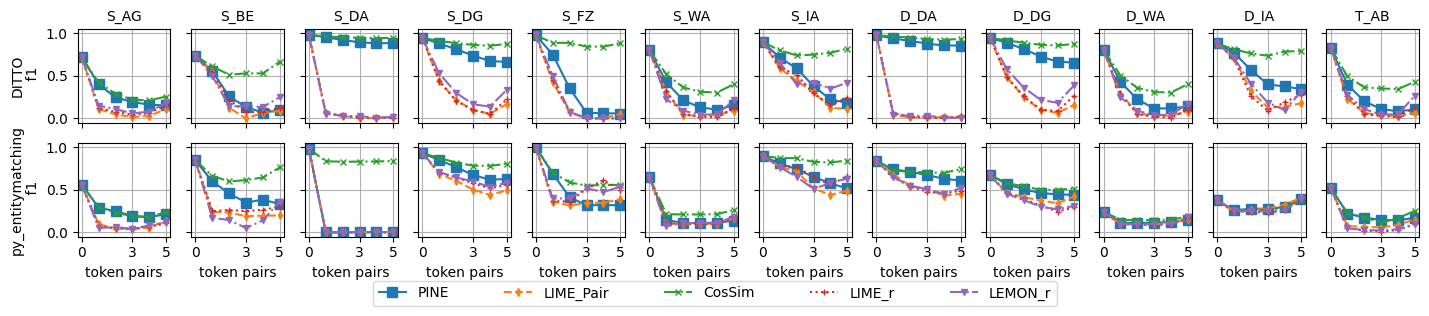

bert_mini
magellan


method                       PINE         LIME_Pair          CosSim          \
metric                    ranking      F1   ranking      F1 ranking      F1   
Matcher           dataset                                                     
DITTO             S_AG     2.0000  0.1612    5.0000  0.0297  1.0000  0.2123   
                  S_BE     4.0000  0.0667    5.0000  0.0645  1.0000  0.5294   
                  S_DA     2.0000  0.8841    4.0000  0.0036  1.0000  0.9444   
                  S_DG     2.0000  0.6748    4.0000  0.0539  1.0000  0.8554   
                  S_FZ     2.0000  0.0606    3.0000  0.0000  1.0000  0.8444   
                  S_WA     2.0000  0.1028    4.0000  0.0402  1.0000  0.3042   
                  S_IA     3.0000  0.2222    5.0000  0.1224  1.0000  0.7719   
                  D_DA     2.0000  0.8575    3.0000  0.0117  1.0000  0.9261   
                  D_DG     2.0000  0.6675    5.0000  0.0649  1.0000  0.8578   
                  D_WA     2.0000  0.1184    4.0000  0.0343  1.0000  0.3041   
                  D_IA     2.0000  0.3750    4.0000  0.1379  1.0000  0.7857   
                  T_AB     2.0000  0.0826    4.0000  0.0280  1.0000  0.3451   
py_entitymatching S_AG     1.0000  0.1813    5.0000  0.0547  2.0000  0.1764   
                  S_BE     2.0000  0.3860    4.0000  0.1967  1.0000  0.6471   
                  S_DA     3.0000  0.0042    4.0000  0.0040  1.0000  0.8350   
                  S_DG     2.0000  0.6213    5.0000  0.4404  1.0000  0.7834   
                  S_FZ     5.0000  0.3193    4.0000  0.3495  2.0000  0.5588   
                  S_WA     2.0000  0.1130    4.0000  0.1033  1.0000  0.2153   
                  S_IA     3.0000  0.5769    5.0000  0.4407  1.0000  0.8235   
                  D_DA     2.0000  0.6308    5.0000  0.4326  1.0000  0.7011   
                  D_DG     2.0000  0.4476    3.0000  0.3441  1.0000  0.5034   
                  D_WA     2.0000  0.1229    3.0000  0.1146  1.0000  0.1478   
                  D_IA     2.0000  0.2975    1.0000  0.3279  3.0000  0.2857   
                  T_AB     2.0000  0.1425    3.0000  0.0891  1.0000  0.1679   
Mean                       2.3333  0.3203    3.8333  0.2415  1.3333  0.4871   

method                     LIME_r         LEMON_r          
metric                    ranking      F1 ranking      F1  
Matcher           dataset                                  
DITTO             S_AG     4.0000  0.0605  3.0000  0.0790  
                  S_BE     3.0000  0.0769  2.0000  0.1333  
                  S_DA     5.0000  0.0000  3.0000  0.0088  
                  S_DG     5.0000  0.0507  3.0000  0.1370  
                  S_FZ     3.0000  0.0000  3.0000  0.0000  
                  S_WA     5.0000  0.0181  3.0000  0.0479  
                  S_IA     4.0000  0.1579  2.0000  0.3500  
                  D_DA     5.0000  0.0044  4.0000  0.0088  
                  D_DG     4.0000  0.0854  3.0000  0.1833  
                  D_WA     5.0000  0.0085  3.0000  0.0426  
                  D_IA     3.0000  0.1905  5.0000  0.0976  
                  T_AB     5.0000  0.0159  3.0000  0.0481  
py_entitymatching S_AG     4.0000  0.0684  3.0000  0.0836  
                  S_BE     3.0000  0.2667  5.0000  0.1429  
                  S_DA     5.0000  0.0000  2.0000  0.0044  
                  S_DG     4.0000  0.5199  3.0000  0.5347  
                  S_FZ     1.0000  0.6129  3.0000  0.4746  
                  S_WA     5.0000  0.1014  3.0000  0.1105  
                  S_IA     4.0000  0.5581  2.0000  0.5833  
                  D_DA     3.0000  0.4558  4.0000  0.4525  
                  D_DG     5.0000  0.2447  4.0000  0.2711  
                  D_WA     5.0000  0.0914  4.0000  0.0982  
                  D_IA     5.0000  0.2581  4.0000  0.2623  
                  T_AB     5.0000  0.0271  4.0000  0.0381  
Mean                       4.0833  0.2670  3.4167  0.2547

In [19]:
display_contribution_graph(match_side=True, show_table=False)

loading data for bert_mini
making side: unmatch


100%|██████████| 12/12 [00:01<00:00,  7.79it/s]


loading data for magellan
making side: unmatch


100%|██████████| 12/12 [00:01<00:00,  7.65it/s]


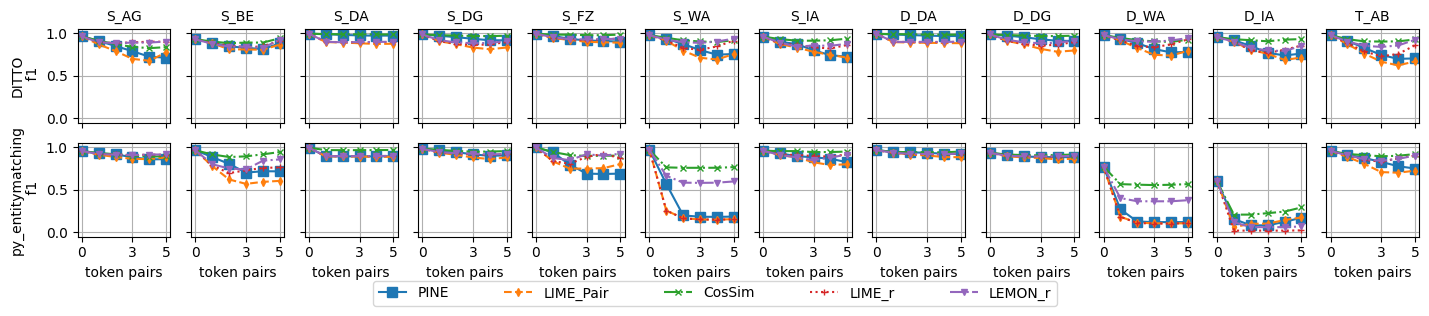

bert_mini
magellan


method                       PINE         LIME_Pair          CosSim          \
metric                    ranking      F1   ranking      F1 ranking      F1   
Matcher           dataset                                                     
DITTO             S_AG       4.00  0.7261       5.0  0.6775    3.00  0.8262   
                  S_BE       4.00  0.8158       5.0  0.8079    1.00  0.8919   
                  S_DA       2.00  0.9734       5.0  0.8753    1.00  0.9876   
                  S_DG       2.00  0.9190       5.0  0.8134    1.00  0.9677   
                  S_FZ       4.00  0.9101       5.0  0.8947    1.00  0.9790   
                  S_WA       4.00  0.7493       5.0  0.6927    2.00  0.8975   
                  S_IA       5.00  0.7439       4.0  0.7456    1.00  0.9193   
                  D_DA       2.00  0.9690       5.0  0.8861    1.00  0.9840   
                  D_DG       2.00  0.9127       5.0  0.7837    1.00  0.9685   
                  D_WA       4.00  0.7768       5.0  0.7382    2.00  0.9004   
                  D_IA       4.00  0.7403       5.0  0.6875    1.00  0.9259   
                  T_AB       4.00  0.7001       5.0  0.6235    1.00  0.9060   
py_entitymatching S_AG       5.00  0.8592       4.0  0.8618    3.00  0.8917   
                  S_BE       4.00  0.7200       5.0  0.5950    1.00  0.9189   
                  S_DA       4.00  0.8942       5.0  0.8885    1.00  0.9687   
                  S_DG       4.00  0.9009       5.0  0.8631    1.00  0.9515   
                  S_FZ       5.00  0.6873       4.0  0.7564    2.00  0.9032   
                  S_WA       3.00  0.1828       5.0  0.1493    1.00  0.7609   
                  S_IA       4.00  0.8675       5.0  0.7925    1.00  0.9461   
                  D_DA       2.00  0.9268       5.0  0.8867    1.00  0.9429   
                  D_DG       4.00  0.8859       5.0  0.8588    1.00  0.9111   
                  D_WA       3.00  0.1212       4.0  0.1059    1.00  0.5607   
                  D_IA       3.00  0.1237       2.0  0.1458    1.00  0.2453   
                  T_AB       4.00  0.7787       5.0  0.7027    1.00  0.9017   
Mean                         3.75  0.6624       4.5  0.6339    1.25  0.8252   

method                     LIME_r         LEMON_r          
metric                    ranking      F1 ranking      F1  
Matcher           dataset                                  
DITTO             S_AG     1.0000  0.9028  2.0000  0.8921  
                  S_BE     2.0000  0.8462  3.0000  0.8289  
                  S_DA     4.0000  0.8972  3.0000  0.8996  
                  S_DG     4.0000  0.8701  3.0000  0.8872  
                  S_FZ     2.0000  0.9322  2.0000  0.9322  
                  S_WA     3.0000  0.8465  1.0000  0.9038  
                  S_IA     3.0000  0.8222  2.0000  0.8539  
                  D_DA     4.0000  0.8984  3.0000  0.9001  
                  D_DG     4.0000  0.8676  3.0000  0.8899  
                  D_WA     3.0000  0.8716  1.0000  0.9164  
                  D_IA     2.0000  0.8068  3.0000  0.7910  
                  T_AB     3.0000  0.7577  2.0000  0.8575  
py_entitymatching S_AG     2.0000  0.9158  1.0000  0.9165  
                  S_BE     3.0000  0.7591  2.0000  0.8442  
                  S_DA     3.0000  0.8970  2.0000  0.8991  
                  S_DG     3.0000  0.9116  2.0000  0.9167  
                  S_FZ     1.0000  0.9241  3.0000  0.9028  
                  S_WA     4.0000  0.1500  2.0000  0.5853  
                  S_IA     2.0000  0.8914  3.0000  0.8824  
                  D_DA     4.0000  0.9184  3.0000  0.9198  
                  D_DG     3.0000  0.8904  2.0000  0.8950  
                  D_WA     5.0000  0.1037  2.0000  0.3664  
                  D_IA     5.0000  0.0213  4.0000  0.0625  
                  T_AB     2.0000  0.8728  3.0000  0.8649  
Mean                       3.0833  0.6880  2.4167  0.7546

In [20]:
display_contribution_graph(match_side=False, show_table=False)

## Token Pair Semantic Relevance 

- 用いる類似度
  - CosSim
  - Wu and Palmer
- 標準化+Sigmoid
  - あり
  - なし
- null token
  - 平均
  - 非類似度

In [21]:
from typing import Callable
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
import pandas as pd


def _get_average(
    scores: List[np.ndarray],
    axis: int = 0,
    max_length: int = None,
    mode: str = "edge",
    constant_values: float = np.nan,
    dump: bool = False,
) -> np.ndarray:
    if max_length is None:
        max_length = max([len(s) for s in scores])
    if mode == "constant":
        scores = [
            np.pad(
                s[:max_length].astype(float),
                (0, max_length - s[:max_length].shape[0]),
                mode="constant",
                constant_values=constant_values,
            )
            if len(s) != 0
            else np.array([np.nan] * max_length)
            for s in scores
        ]
    else:
        scores = [
            np.pad(
                s[:max_length].astype(float),
                (0, max_length - s[:max_length].shape[0]),
                mode=mode,
            )
            if len(s) != 0
            else np.array([np.nan] * max_length)
            for s in scores
        ]
    if dump:
        print(scores)
    if len(scores) == 0:
        return np.zeros((max_length,))
    scores = np.vstack(scores)
    return np.nanmean(scores, axis=axis)


In [22]:
import numpy as np
from scipy.special import expit  # sigmoid


def calc_stat(token_sim):
    all_sims = np.concatenate(
        [list(idx_to_score.values()) for idx_to_score in token_sim.values()]
    ).astype(float)

    mu = np.nanmean(all_sims)
    sigma = np.nanstd(all_sims)
    return mu, sigma


def standardization(sim, mu, sigma):
    z = (sim - mu) / sigma
    return expit(z)


def calc_dis_sim_score(sims, is_standardization: bool, mu: float, sigma: float):
    if is_standardization:
        scores = standardization(np.array(sims), mu, sigma)
    else:
        scores = np.array(sims)
    return 1.0 - np.nanmean(scores)


def calc_token_rel_score(
    segment_idx,
    entity_pair,
    token_sim_in_data,
    is_standardization: bool,
    is_calc_null_token_dissim: bool,
    mu: float,
    sigma: float,
) -> float:
    score = None
    is_null_token = False
    is_not_exist = False

    token_l_idxs, token_r_idxs = entity_pair.convert_segment_idx_to_entity_idx(
        segment_idx
    )

    # null token の場合は計算して返す
    if len(token_l_idxs) == 0 or len(token_r_idxs) == 0:
        is_null_token = True

        # null_token を計算しない場合は、Noneを返す
        if not is_calc_null_token_dissim:
            return None, is_null_token, is_not_exist

        t_sims_in_other_record = []
        if len(token_l_idxs) == 0:
            token_l_idxs = list(range(entity_pair.entity_l.segment_size()))
        elif len(token_r_idxs) == 0:
            token_r_idxs = list(range(entity_pair.entity_r.segment_size()))
        else:
            raise ValueError("token_l_idxs and token_r_idxs are empty.")
        for token_l_idx in token_l_idxs:
            for token_r_idx in token_r_idxs:
                t_sims_in_other_record.append(
                    token_sim_in_data[(token_l_idx, token_r_idx)]
                )
        t_sims_in_other_record = np.array(t_sims_in_other_record).astype(float)
        # もしレコード内の単語が存在しない、または、全て類似度がNoneの場合は、見つからない
        if len(t_sims_in_other_record) == 0 or np.all(np.isnan(t_sims_in_other_record)):
            is_not_exist = True
            return None, is_null_token, is_not_exist
        score = calc_dis_sim_score(
            t_sims_in_other_record,
            is_standardization,
            mu,
            sigma,
        )
        return score, is_null_token, is_not_exist

    sim = token_sim_in_data[(token_l_idxs[0], token_r_idxs[0])]
    if sim is None:
        is_not_exist = True
        return None, is_null_token, is_not_exist
    if is_standardization:
        score = standardization(sim, mu, sigma)
    else:
        score = sim
    return score, is_null_token, is_not_exist


In [23]:
def make_token_rel_score_data(
    dataset_name,
    matcher_name,
    method_name,
    root_dir,
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    """token pairの類似度を取得する
    Args:
        dataset_name (str): データセット名
        matcher_name (str): マッチャー名
        method_name (str): 手法名
        root_dir (str): データセットのルートディレクトリ
        sim_kind (str): 類似度の種類
        is_standardization (bool): 標準化するかどうか
        is_calc_null_token_dissim (bool): null token pairの類似度を計算するかどうか
    Returns:
        dict: token pair relative score
        dict: token pair type to number
    """
    # データセット内の全token pairの類似度を取得する
    if sim_kind == "cos":
        token_sim = load_token_sim_score(
            dataset_name,
            pathlib.Path(token_sim_result_root_dir),
        )
    elif sim_kind == "wup":
        token_sim = load_token_sim_score(
            dataset_name,
            pathlib.Path(token_sim_wup_result_root_dir),
        )
    else:
        raise ValueError("Invalid sim_kind: {}".format(sim_kind))

    # explanationsを取得する
    pair_explanations = load_pair_explanations(
        method_name,
        dataset_name,
        matcher_name,
        pathlib.Path(root_dir),
    )

    # 全体の平均と標準偏差を計算
    mu, sigma = calc_stat(token_sim)
    # print(
    #     dataset_name,
    #     matcher_name,
    #     method_name,
    #     "mu=",
    #     mu,
    #     "sigma=",
    #     sigma,
    # )
    # 説明内のtoken pairの類似度を取得する
    token_rel_score_data = {}
    # 以下の統計データを出力する
    token_pair_type_to_num = {
        "null_token_and_not_exist": 0,
        "not_null_token_and_not_exist": 0,
        "null_token_and_exist": 0,
        "not_null_token_and_exist": 0,
    }
    for data_id in pair_explanations.keys():
        pair_exp, entity_pair = pair_explanations[data_id]
        scores = []
        for attr in pair_exp.attributions:
            # スコア計算
            token_l_idx, token_r_idx = entity_pair.convert_segment_idx_to_entity_idx(
                attr.index
            )
            score, is_null_token, is_not_exist = calc_token_rel_score(
                attr.index,
                entity_pair,
                token_sim[data_id],
                is_standardization,
                is_calc_null_token_dissim,
                mu,
                sigma,
            )
            scores.append(score)
        token_rel_score_data[data_id] = np.array(scores)
        if is_null_token and is_not_exist:
            token_pair_type_to_num["null_token_and_not_exist"] += 1
        elif is_null_token and not is_not_exist:
            token_pair_type_to_num["null_token_and_exist"] += 1
        elif not is_null_token and is_not_exist:
            token_pair_type_to_num["not_null_token_and_not_exist"] += 1
        elif not is_null_token and not is_not_exist:
            token_pair_type_to_num["not_null_token_and_exist"] += 1

    return token_rel_score_data, token_pair_type_to_num

In [24]:
from collections import defaultdict


def nan_stats(array_list):
    # 全要素を一つの1次元配列に結合
    all_values = np.concatenate(array_list)

    # NaNを無視して統計量を計算
    min_val = np.nanmin(all_values)
    max_val = np.nanmax(all_values)
    avg_val = np.nanmean(all_values)

    return min_val, max_val, avg_val


@lru_cache(maxsize=None)
def make_token_rel_score_average_data(
    match_score_func,
    grand_truth,
    topk=5,
    fill_na="avg",
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    """token pair relevance score の平均を計算"""
    matcher_to_dataset_to_methods_to_token_rel = {}
    matcher_to_dataset_to_methods_to_token_rel_stat = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
        matcher_to_dataset_to_methods_to_token_rel[target_matcher_name] = {}
        print("loading data for", target_matcher_name)
        for target_dataset_name in tqdm(
            [dataset_names[j] for j in target_dataset_idxs]
        ):
            matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                target_dataset_name
            ] = {}
            dataset = load_dataset(target_dataset_name, dataset_root_dir)
            lime_results = load_lime_result(
                target_dataset_name,
                target_matcher_name,
                pathlib.Path(lime_result_root_dir),
            )
            # 条件に合うdata_idを取得
            data_ids = get_data_ids(
                dataset, lime_results, match_score_func, grand_truth, dump=False
            )
            for target_method_name in [methods[k] for k in target_method_idxs]:
                matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = {}
                # rel score データ作成
                rel_scores, rel_scores_stat = make_token_rel_score_data(
                    target_dataset_name,
                    target_matcher_name,
                    target_method_name,
                    eval_data_root_dir,
                    sim_kind=sim_kind,
                    is_standardization=is_standardization,
                    is_calc_null_token_dissim=is_calc_null_token_dissim,
                )
                # 上位kまでの全体の平均を取る。
                # TODO: この部分は、もう少し綺麗に書けるはず。
                rel_score_avgs = []
                for target_rank in range(1, topk + 1):
                    # nanを埋める値を計算
                    (
                        rel_score_min_wholl_data,
                        rel_score_max_wholl_data,
                        rel_score_avg_wholl_data,
                    ) = nan_stats(
                        [
                            scores[:target_rank].astype(float)
                            for scores in rel_scores.values()
                        ],
                    )
                    if fill_na == "min":
                        rel_score_fill_na = rel_score_min_wholl_data
                    elif fill_na == "max":
                        rel_score_fill_na = rel_score_max_wholl_data
                    elif fill_na == "avg":
                        rel_score_fill_na = rel_score_avg_wholl_data
                    else:
                        raise ValueError(f"Invalid fill_na value: {fill_na}")

                    # 条件に合うdata_idのみで平均を計算。Noneの部分には、fill_naを入れる。
                    rel_score_avg_target = _get_average(
                        [
                            np.nan_to_num(
                                rel_scores[data_id][:target_rank].astype(float),
                                nan=rel_score_fill_na,
                            )
                            for data_id in data_ids
                        ],
                        axis=None,
                        mode="constant",
                        constant_values=np.nan,
                    )
                    rel_score_avgs.append(rel_score_avg_target)

                matcher_to_dataset_to_methods_to_token_rel[target_matcher_name][
                    target_dataset_name
                ][target_method_name] = rel_score_avgs
                matcher_to_dataset_to_methods_to_token_rel_stat[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = rel_scores_stat
    return matcher_to_dataset_to_methods_to_token_rel, matcher_to_dataset_to_methods_to_token_rel_stat


In [25]:
def display_token_rel_score_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = False,
    fill_na: str = "avg",
    sim_kind: str = "cos",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(tokensim)
    matcher_to_dataset_to_methods_to_token_rel, matcher_to_dataset_to_methods_to_token_rel_stat = make_token_rel_score_average_data(
        match_score_func,
        grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_token_rel, "cosine sim", x_axis_start=1
    )
    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_token_rel[
                    target_matcher_name
                ],
                TOP_N,
                "Token Rel",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)

    return

### CosineSim Avg

loading data for bert_mini


100%|██████████| 12/12 [00:58<00:00,  4.89s/it]


loading data for magellan


100%|██████████| 12/12 [00:48<00:00,  4.07s/it]


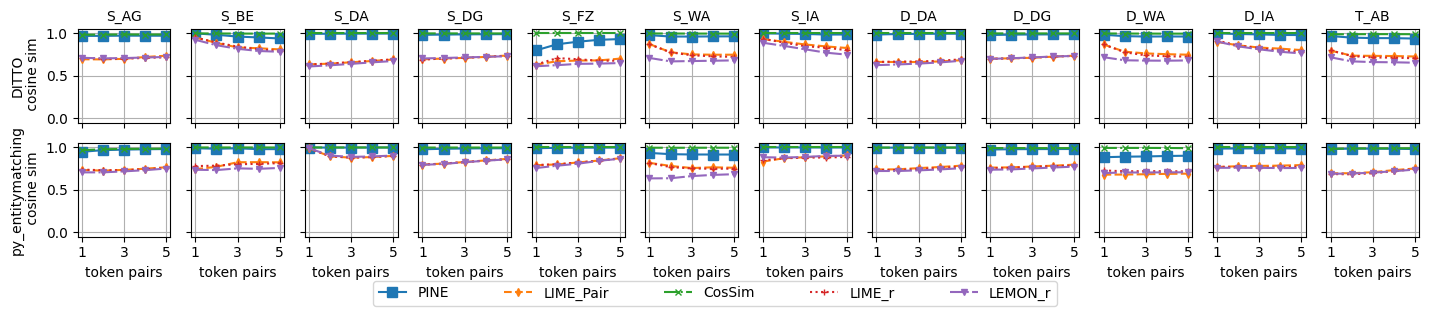

In [26]:
display_token_rel_score_graph(
    match_score_func=lambda x: x >= 0.0,
    fill_na="avg",
    sim_kind="cos",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

loading data for bert_mini


100%|██████████| 12/12 [00:28<00:00,  2.36s/it]


loading data for magellan


100%|██████████| 12/12 [00:30<00:00,  2.58s/it]


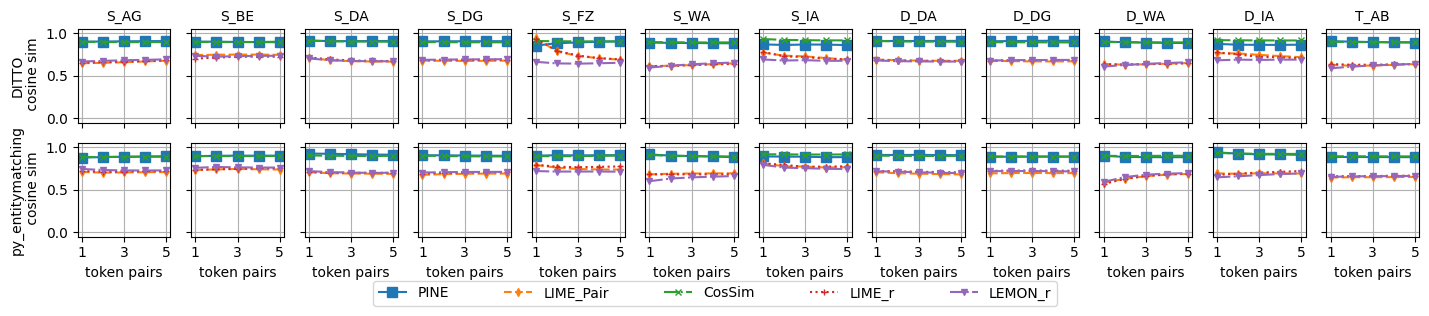

In [27]:
display_token_rel_score_graph(
    match_score_func=lambda x: x < 0.0,
    fill_na="avg",
    sim_kind="cos",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

### 類似度とfaithfulを組み合わせた指標

- faithful の unmatch については、全く関係ない単語の組合せのほうが上がりやすい仕組みになっている
- 塁維持度合とfaithfulを組み合わせた指標を考えてみる
  
$
post-hoc-accuracy(k) = 1 / M \sum_{m=1}^{M}  [[ y^{(m)} = y_{k}^{(m)} ]]
$

$
token-pair-simirarity(k) = 1 / M \sum_{m=1}^{M} 1 / k \sum_{k=1}^{k} WupSim(<t_1, t_2>_k^{(m)})
$

$
post-hoc-accuracy-with-token-sim(k) = post-hoc-accuracy(k) * token-pair-simirarity(k)
$

In [40]:
def display_faithful_with_token_sim_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    fill_na: str = "avg",
    sim_kind: str = "wup",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(faitful)
    matcher_to_dataset_to_methods_to_posthoc_acc = make_faithful_graph_data(
        match_score_func, grand_truth
    )
    # グラフ描画用データ取得(tokenrel)
    matcher_to_dataset_to_methods_to_token_sim, _ = make_token_rel_score_average_data(
        match_score_func, grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # 積算
    matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim = {}
    for target_matcher_name in [
        matcher_names[target_matcher_idx] for target_matcher_idx in target_matcher_idxs
    ]:
        matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
            target_matcher_name
        ] = {}
        for target_dataset_name in [
            dataset_names[target_dataset_idx]
            for target_dataset_idx in target_dataset_idxs
        ]:
            matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                target_matcher_name
            ][target_dataset_name] = {}
            for target_method_name in [methods[k] for k in target_method_idxs]:
                post_hoc_accs = np.array(
                    matcher_to_dataset_to_methods_to_posthoc_acc[target_matcher_name][
                        target_dataset_name
                    ][target_method_name]["accuracy"][1 : TOP_N + 1]
                )
                token_sim = np.array(
                    matcher_to_dataset_to_methods_to_token_sim[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][:TOP_N]
                )
                matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = post_hoc_accs * token_sim

    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim, "acc with rel"
    )
    display_graph(matcher_to_dataset_to_methods_to_token_sim, "token rel")

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_acc_with_token_sim[
                    target_matcher_name
                ],
                TOP_N,
                "post_hoc_acc",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

### 類似度とContributeを組み合わせた指標

- Contribute の match については、全く関係ない単語の組合せのほうが下がりやすい
- 類似度とContributeを組み合わせた指標を考えてみる
  
$
F1(label, k) = 2 * Precision(label, k) * Recall(label, k) / (Precision(label, k) + Recall(label, k))
$

$
Precition(label,k) = {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] [[ y_{true}^{(m)} = label ]] } / {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] }
$

$
Recall(label,k) = {\sum_{m=1}^{M} [[ y_{del_k}^{(m)} = label ]] [[ y_{true}^{(m)} = label ]] } / {\sum_{m=1}^{M} [[ y_{true}^{(m)} = label ]] }
$

$
token-pair-simirarity(k) = 1 / M \sum_{m=1}^{M} 1 / k \sum_{k=1}^{k} WupSim(<t_1, t_2>_k^{(m)})
$

$
F1-with-token-sim(k) = ( 1 - F1(k) ) * token-pair-simirarity(k)
$

In [44]:
def display_contribution_with_token_sim_graph(
    match_score_func: Callable = None,
    grand_truth: bool = None,
    show_table: bool = True,
    match_side: bool = True,
    fill_na: str = "avg",
    sim_kind: str = "wup",
    is_standardization: bool = False,
    is_calc_null_token_dissim: bool = False,
):
    # グラフ描画用データ取得(contribution)
    matcher_to_dataset_to_methods_to_posthoc_f1 = make_contribution_graph_data(
        match_score_func, grand_truth, match_side
    )
    # グラフ描画用データ取得(tokensim)
    matcher_to_dataset_to_methods_to_token_sim, _ = make_token_rel_score_average_data(
        match_score_func, grand_truth,
        fill_na=fill_na,
        sim_kind=sim_kind,
        is_standardization=is_standardization,
        is_calc_null_token_dissim=is_calc_null_token_dissim,
    )
    # 積算
    matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim = {}
    for target_matcher_name in [
        matcher_names[target_matcher_idx] for target_matcher_idx in target_matcher_idxs
    ]:
        matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
            target_matcher_name
        ] = {}
        for target_dataset_name in [
            dataset_names[target_dataset_idx]
            for target_dataset_idx in target_dataset_idxs
        ]:
            matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                target_matcher_name
            ][target_dataset_name] = {}
            for target_method_name in [methods[k] for k in target_method_idxs]:
                post_hoc_f1s = np.array(
                    matcher_to_dataset_to_methods_to_posthoc_f1[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][1 : TOP_N + 1]
                )
                token_sim = np.array(
                    matcher_to_dataset_to_methods_to_token_sim[target_matcher_name][
                        target_dataset_name
                    ][target_method_name][:TOP_N]
                )
                matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                    target_matcher_name
                ][target_dataset_name][target_method_name] = (
                    1 - post_hoc_f1s
                ) * token_sim

    # グラフ描画
    display_graph(
        matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim, "f1 with sim"
    )

    # テーブル出力
    if show_table:
        dfs = []
        for target_matcher_name in [matcher_names[i] for i in target_matcher_idxs]:
            print(target_matcher_name)
            df = make_ranking_table(
                matcher_to_dataset_to_methods_to_posthoc_f1_with_token_sim[
                    target_matcher_name
                ],
                TOP_N,
                "F1",
            )
            dfs.append(df)
        df_concatenated = pd.concat(
            dfs,
            keys=[matcher_names_maps[matcher_names[i]] for i in target_matcher_idxs],
            names=["Matcher"],
        )
        # 最後の行に、各列の平均値を追加
        df_concatenated.loc[("Mean", ""), :] = df.mean(numeric_only=True).round(4)
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            display(df_concatenated)
    return

loading data for bert_mini


100%|██████████| 12/12 [00:01<00:00,  6.95it/s]


loading data for magellan


100%|██████████| 12/12 [00:01<00:00,  7.25it/s]


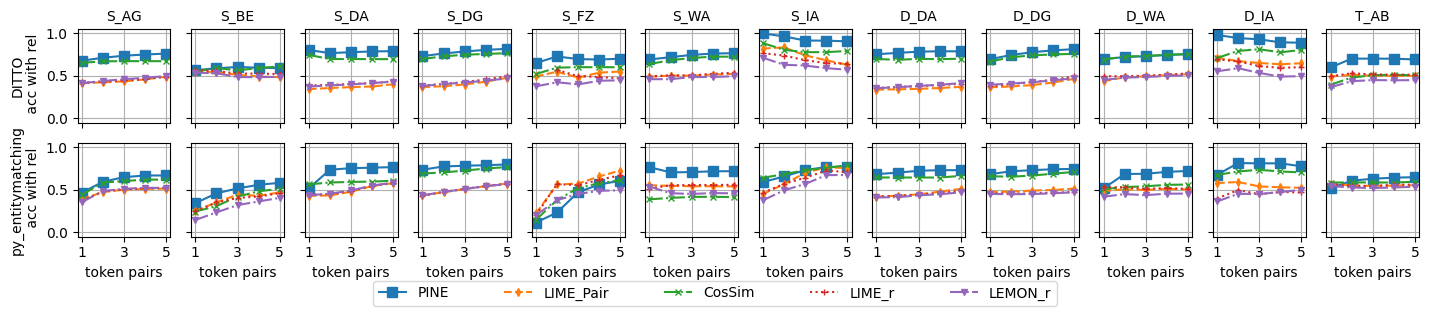

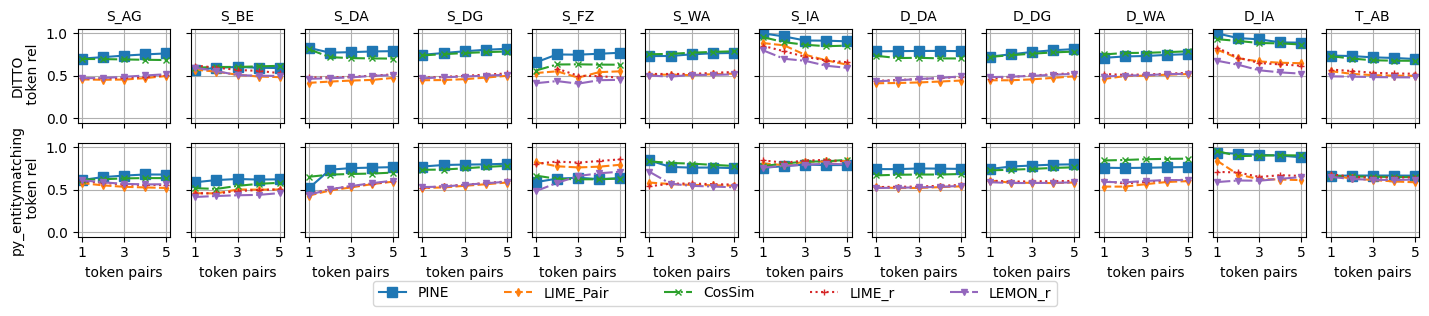

bert_mini
magellan


method                       PINE              LIME_Pair               CosSim  \
metric                    ranking post_hoc_acc   ranking post_hoc_acc ranking   
Matcher           dataset                                                       
DITTO             S_AG     1.0000       0.7626    4.0000       0.4914    2.00   
                  S_BE     2.0000       0.5919    5.0000       0.4850    1.00   
                  S_DA     1.0000       0.7909    5.0000       0.4012    2.00   
                  S_DG     1.0000       0.8179    4.0000       0.4775    2.00   
                  S_FZ     1.0000       0.7027    3.0000       0.5506    2.00   
                  S_WA     1.0000       0.7669    4.0000       0.5228    2.00   
                  S_IA     1.0000       0.9064    4.0000       0.6313    2.00   
                  D_DA     1.0000       0.7884    5.0000       0.3704    2.00   
                  D_DG     1.0000       0.8146    5.0000       0.4667    2.00   
                  D_WA     2.0000       0.7554    4.0000       0.5192    1.00   
                  D_IA     1.0000       0.8906    3.0000       0.6488    2.00   
                  T_AB     1.0000       0.6935    4.0000       0.5002    3.00   
py_entitymatching S_AG     1.0000       0.6706    5.0000       0.5147    2.00   
                  S_BE     1.0000       0.5838    3.0000       0.4714    2.00   
                  S_DA     1.0000       0.7684    5.0000       0.5812    2.00   
                  S_DG     1.0000       0.7998    3.0000       0.5754    2.00   
                  S_FZ     4.0000       0.6081    1.0000       0.7286    3.00   
                  S_WA     1.0000       0.7209    3.0000       0.5404    5.00   
                  S_IA     2.0000       0.7711    3.0000       0.7564    1.00   
                  D_DA     1.0000       0.7324    3.0000       0.5131    2.00   
                  D_DG     1.0000       0.7471    3.0000       0.5164    2.00   
                  D_WA     1.0000       0.7229    4.0000       0.5047    2.00   
                  D_IA     1.0000       0.7781    3.0000       0.5252    2.00   
                  T_AB     1.0000       0.6503    4.0000       0.5545    2.00   
Mean                       1.3333       0.7128    3.3333       0.5652    2.25   

method                                  LIME_r              LEMON_r  \
metric                    post_hoc_acc ranking post_hoc_acc ranking   
Matcher           dataset                                             
DITTO             S_AG          0.6728  5.0000       0.4909     3.0   
                  S_BE          0.6117  3.0000       0.5207     4.0   
                  S_DA          0.6967  3.0000       0.4355     4.0   
                  S_DG          0.7671  3.0000       0.4960     5.0   
                  S_FZ          0.6014  4.0000       0.4703     5.0   
                  S_WA          0.7256  3.0000       0.5369     5.0   
                  S_IA          0.7932  3.0000       0.6422     5.0   
                  D_DA          0.7015  4.0000       0.4061     3.0   
                  D_DG          0.7595  3.0000       0.4941     4.0   
                  D_WA          0.7568  3.0000       0.5279     5.0   
                  D_IA          0.8053  4.0000       0.6022     5.0   
                  T_AB          0.5070  2.0000       0.5135     5.0   
py_entitymatching S_AG          0.6212  4.0000       0.5231     3.0   
                  S_BE          0.5135  4.0000       0.4614     5.0   
                  S_DA          0.6084  4.0000       0.5819     3.0   
                  S_DG          0.7692  4.0000       0.5717     5.0   
                  S_FZ          0.6140  2.0000       0.6734     5.0   
                  S_WA          0.4161  2.0000       0.5608     4.0   
                  S_IA          0.7919  4.0000       0.7105     5.0   
                  D_DA          0.6656  4.0000       0.4864     5.0   
                  D_DG          0.7124  4.0000       0.4744     5.0   
                  D_WA     

In [53]:
display_faithful_with_token_sim_graph(
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

loading data for bert_mini
making side: match


100%|██████████| 12/12 [00:01<00:00,  7.97it/s]


loading data for magellan
making side: match


100%|██████████| 12/12 [00:01<00:00,  8.00it/s]


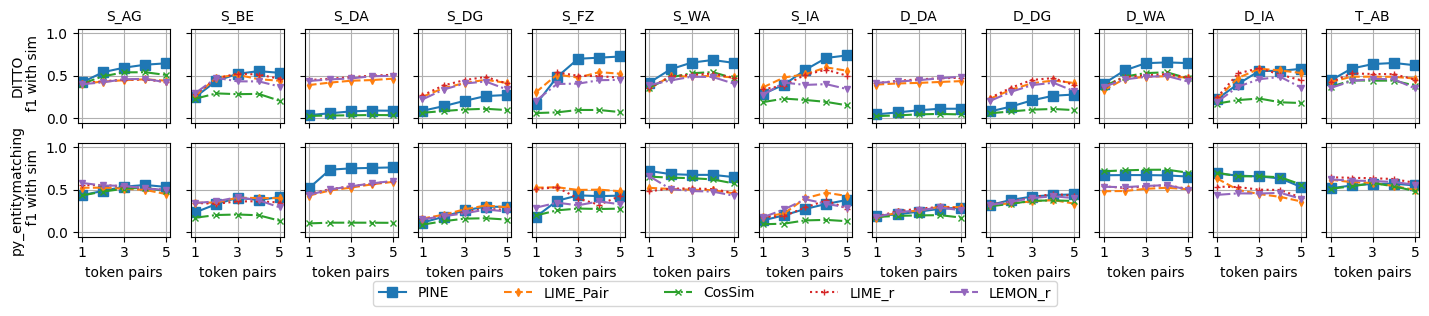

bert_mini
magellan


method                       PINE         LIME_Pair          CosSim          \
metric                    ranking      F1   ranking      F1 ranking      F1   
Matcher           dataset                                                     
DITTO             S_AG     1.0000  0.6480    3.0000  0.4432  2.0000  0.5103   
                  S_BE     1.0000  0.5356    3.0000  0.4428  5.0000  0.2062   
                  S_DA     4.0000  0.0900    3.0000  0.4674  5.0000  0.0377   
                  S_DG     4.0000  0.2748    1.0000  0.4167  5.0000  0.0976   
                  S_FZ     1.0000  0.7281    2.0000  0.5251  5.0000  0.0734   
                  S_WA     1.0000  0.6529    2.0000  0.4812  4.0000  0.4715   
                  S_IA     1.0000  0.7416    2.0000  0.5598  5.0000  0.1529   
                  D_DA     4.0000  0.1132    3.0000  0.4382  5.0000  0.0463   
                  D_DG     4.0000  0.2804    1.0000  0.4158  5.0000  0.0973   
                  D_WA     1.0000  0.6503    3.0000  0.4793  4.0000  0.4705   
                  D_IA     1.0000  0.5835    2.0000  0.5329  5.0000  0.1804   
                  T_AB     1.0000  0.6250    2.0000  0.4686  4.0000  0.3855   
py_entitymatching S_AG     1.0000  0.5352    5.0000  0.4508  4.0000  0.4837   
                  S_BE     1.0000  0.4167    2.0000  0.4037  5.0000  0.1374   
                  S_DA     1.0000  0.7651    4.0000  0.5952  5.0000  0.1127   
                  S_DG     1.0000  0.3004    2.0000  0.2962  5.0000  0.1512   
                  S_FZ     2.0000  0.4329    1.0000  0.4845  5.0000  0.2797   
                  S_WA     1.0000  0.6511    4.0000  0.4592  2.0000  0.5763   
                  S_IA     2.0000  0.3828    1.0000  0.4275  5.0000  0.1315   
                  D_DA     2.0000  0.2920    1.0000  0.2959  5.0000  0.1749   
                  D_DG     1.0000  0.4470    5.0000  0.3384  4.0000  0.3701   
                  D_WA     2.0000  0.6572    4.0000  0.5086  1.0000  0.7033   
                  D_IA     2.0000  0.5329    5.0000  0.3635  1.0000  0.5620   
                  T_AB     3.0000  0.5531    4.0000  0.5003  5.0000  0.4870   
Mean                       1.5833  0.4972    3.1667  0.4270  3.9167  0.3475   

method                     LIME_r         LEMON_r          
metric                    ranking      F1 ranking      F1  
Matcher           dataset                                  
DITTO             S_AG       4.00  0.4268  5.0000  0.4246  
                  S_BE       2.00  0.4658  4.0000  0.3744  
                  S_DA       1.00  0.5129  2.0000  0.5013  
                  S_DG       2.00  0.4106  3.0000  0.3409  
                  S_FZ       3.00  0.4779  4.0000  0.4530  
                  S_WA       3.00  0.4788  5.0000  0.4083  
                  S_IA       3.00  0.5003  4.0000  0.3439  
                  D_DA       2.00  0.4775  1.0000  0.4914  
                  D_DG       2.00  0.3895  3.0000  0.3185  
                  D_WA       2.00  0.4821  5.0000  0.4339  
                  D_IA       3.00  0.4472  4.0000  0.3599  
                  T_AB       3.00  0.4563  5.0000  0.3522  
py_entitymatching S_AG       2.00  0.4986  3.0000  0.4978  
                  S_BE       3.00  0.3519  4.0000  0.2944  
                  S_DA       3.00  0.6031  2.0000  0.6065  
                  S_DG       3.00  0.2652  4.0000  0.2468  
                  S_FZ       3.00  0.4300  4.0000  0.3300  
                  S_WA       3.00  0.4644  5.0000  0.4318  
                  S_IA       4.00  0.2776  3.0000  0.2929  
                  D_DA       3.00  0.2835  4.0000  0.2606  
                  D_DG       2.00  0.4274  3.0000  0.4037  
                  D_WA       3.00  0.5116  5.0000  0.5043  
                  D_IA       3.00  0.4071  4.0000  0.3951  
                  T_AB       1.00  0.5826  2.0000  0.5608  
Mean                         2.75  0.4252  3.5833  0.4021

In [54]:
display_contribution_with_token_sim_graph(
    match_side=True,
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)

loading data for bert_mini
making side: unmatch


100%|██████████| 12/12 [00:01<00:00,  7.57it/s]


loading data for magellan
making side: unmatch


100%|██████████| 12/12 [00:01<00:00,  7.98it/s]


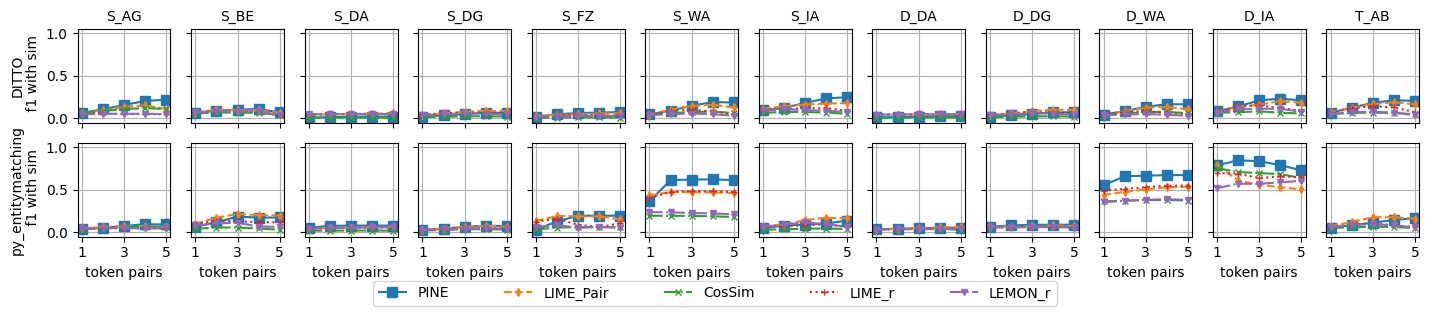

bert_mini
magellan


method                       PINE         LIME_Pair          CosSim          \
metric                    ranking      F1   ranking      F1 ranking      F1   
Matcher           dataset                                                     
DITTO             S_AG       1.00  0.2186      2.00  0.1109  2.0000  0.1109   
                  S_BE       1.00  0.0699      2.00  0.0641  5.0000  0.0359   
                  S_DA       4.00  0.0204      1.00  0.0580  5.0000  0.0083   
                  S_DG       2.00  0.0666      1.00  0.0831  5.0000  0.0213   
                  S_FZ       1.00  0.0743      2.00  0.0604  5.0000  0.0094   
                  S_WA       1.00  0.1866      2.00  0.1280  3.0000  0.0628   
                  S_IA       1.00  0.2502      2.00  0.1798  5.0000  0.0528   
                  D_DA       4.00  0.0245      1.00  0.0514  5.0000  0.0101   
                  D_DG       2.00  0.0724      1.00  0.0995  5.0000  0.0212   
                  D_WA       1.00  0.1654      2.00  0.1067  3.0000  0.0589   
                  D_IA       1.00  0.2115      2.00  0.1842  5.0000  0.0579   
                  T_AB       1.00  0.2057      2.00  0.1650  4.0000  0.0483   
py_entitymatching S_AG       1.00  0.0935      3.00  0.0612  2.0000  0.0660   
                  S_BE       2.00  0.1758      1.00  0.1986  5.0000  0.0316   
                  S_DA       1.00  0.0796      2.00  0.0653  5.0000  0.0211   
                  S_DG       1.00  0.0751      2.00  0.0689  5.0000  0.0335   
                  S_FZ       1.00  0.1965      2.00  0.1559  4.0000  0.0614   
                  S_WA       1.00  0.6159      3.00  0.4637  5.0000  0.1811   
                  S_IA       2.00  0.1388      1.00  0.1661  5.0000  0.0412   
                  D_DA       2.00  0.0575      1.00  0.0622  5.0000  0.0334   
                  D_DG       1.00  0.0914      2.00  0.0774  3.0000  0.0641   
                  D_WA       1.00  0.6755      3.00  0.5388  5.0000  0.3745   
                  D_IA       1.00  0.7298      5.00  0.5073  3.0000  0.6391   
                  T_AB       1.00  0.1656      2.00  0.1615  5.0000  0.0506   
Mean                         1.25  0.2579      2.25  0.2106  4.3333  0.1331   

method                     LIME_r         LEMON_r          
metric                    ranking      F1 ranking      F1  
Matcher           dataset                                  
DITTO             S_AG     4.0000  0.0504  5.0000  0.0497  
                  S_BE     3.0000  0.0449  4.0000  0.0361  
                  S_DA     2.0000  0.0521  3.0000  0.0501  
                  S_DG     3.0000  0.0540  4.0000  0.0458  
                  S_FZ     3.0000  0.0295  4.0000  0.0280  
                  S_WA     4.0000  0.0460  5.0000  0.0314  
                  S_IA     3.0000  0.0892  4.0000  0.0726  
                  D_DA     3.0000  0.0485  2.0000  0.0488  
                  D_DG     3.0000  0.0541  4.0000  0.0445  
                  D_WA     4.0000  0.0378  5.0000  0.0288  
                  D_IA     3.0000  0.0885  4.0000  0.0760  
                  T_AB     3.0000  0.0737  5.0000  0.0362  
py_entitymatching S_AG     4.0000  0.0491  5.0000  0.0469  
                  S_BE     3.0000  0.1190  4.0000  0.0652  
                  S_DA     4.0000  0.0598  3.0000  0.0603  
                  S_DG     3.0000  0.0485  4.0000  0.0443  
                  S_FZ     3.0000  0.1082  5.0000  0.0526  
                  S_WA     2.0000  0.4764  4.0000  0.2124  
                  S_IA     4.0000  0.0662  3.0000  0.0679  
                  D_DA     3.0000  0.0411  4.0000  0.0380  
                  D_DG     4.0000  0.0598  5.0000  0.0571  
                  D_WA     2.0000  0.5516  4.0000  0.3819  
                  D_IA     2.0000  0.6494  4.0000  0.6064  
                  T_AB     3.0000  0.0619  4.0000  0.0590  
Mean                       3.0833  0.1909  4.0833  0.1410

In [55]:
display_contribution_with_token_sim_graph(
    match_side=False,
    show_table=True,
    fill_na="avg",
    sim_kind="wup",
    is_standardization=False,
    is_calc_null_token_dissim=False,
)